# Discriminator Window Sweep Results

Plot results from `discriminator_window_sweep.py`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Path to CSV output from discriminator_window_sweep.py
CSV_PATH = "/home/mila/a/aidan.sirbu/track-mjx/results/rnn/260115_141734_544576_23/window_sweep_data.csv"

In [22]:
df = pd.read_csv(CSV_PATH)
df

,window_size,original_mean,original_std,deterministic_mean,deterministic_std,logvar_-0.5_mean,logvar_-0.5_std,logvar_-1_mean,logvar_-1_std,logvar_-2_mean,logvar_-2_std,logvar_-3_mean,logvar_-3_std,logvar_-4_mean,logvar_-4_std,logvar_0_mean,logvar_0_std,predicted_logvar_mean,predicted_logvar_std
0,10,0.999752,2.220446e-16,0.584787,0.004654,0.699913,0.003459,0.656121,0.004739,0.604802,0.004248,0.568192,0.004694,0.591813,0.004110,0.758061,0.004577,0.690213,0.006022
1,12,0.999747,6.819309e-05,0.590369,0.003701,0.705244,0.005878,0.658533,0.004961,0.615536,0.005187,0.562128,0.004185,0.589955,0.005009,0.783482,0.004600,0.689295,0.005457
2,15,0.999628,1.110223e-16,0.592768,0.005107,0.717801,0.005167,0.669089,0.004858,0.611403,0.004855,0.583281,0.004920,0.591276,0.004447,0.796105,0.006478,0.700249,0.004768
3,16,0.999790,6.140892e-05,0.600483,0.005235,0.705127,0.006106,0.674747,0.003782,0.619122,0.004396,0.577278,0.004191,0.587991,0.005013,0.801835,0.005856,0.704604,0.004655
4,20,0.999752,2.220446e-16,0.606404,0.005273,0.744464,0.004799,0.693844,0.004985,0.613755,0.004591,0.582654,0.004098,0.601186,0.005828,0.809430,0.005350,0.728204,0.003669
5,24,0.999988,8.413462e-05,0.606923,0.005782,0.750703,0.005541,0.709904,0.005230,0.636827,0.004751,0.592085,0.004971,0.605228,0.006933,0.832566,0.005535,0.739784,0.004645
6,30,0.999628,1.110223e-16,0.621622,0.006112,0.756376,0.005558,0.725007,0.005309,0.646734,0.005924,0.605260,0.005360,0.620967,0.005350,0.839330,0.005129,0.756838,0.004783
7,40,0.998861,4.814498e-04,0.628659,0.005073,0.782117,0.006000,0.739375,0.006714,0.642450,0.005807,0.611169,0.006007,0.617208,0.006981,0.842510,0.005607,0.783619,0.004767
8,48,0.998798,1.110223e-16,0.644736,0.006246,0.800216,0.005040,0.747788,0.006442,0.684663,0.005781,0.616911,0.005057,0.641214,0.005964,0.861695,0.007655,0.785469,0.007738
9,60,0.998348,6.866233e-04,0.624137,0.006931,0.792887,0.007083,0.751414,0.008793,0.677470,0.006007,0.632351,0.006194,0.645863,0.005163,0.866979,0.006331,0.794717,0.006929


In [23]:
# Extract dataset names from columns (exclude original and predicted_logvar)
mean_cols = [c for c in df.columns if c.endswith('_mean')]
datasets = [c.replace('_mean', '') for c in mean_cols]
datasets = [d for d in datasets if d not in ('original', 'predicted_logvar')]
print(f"Datasets: {datasets}")

Datasets: ['deterministic', 'logvar_-0.5', 'logvar_-1', 'logvar_-2', 'logvar_-3', 'logvar_-4', 'logvar_0']


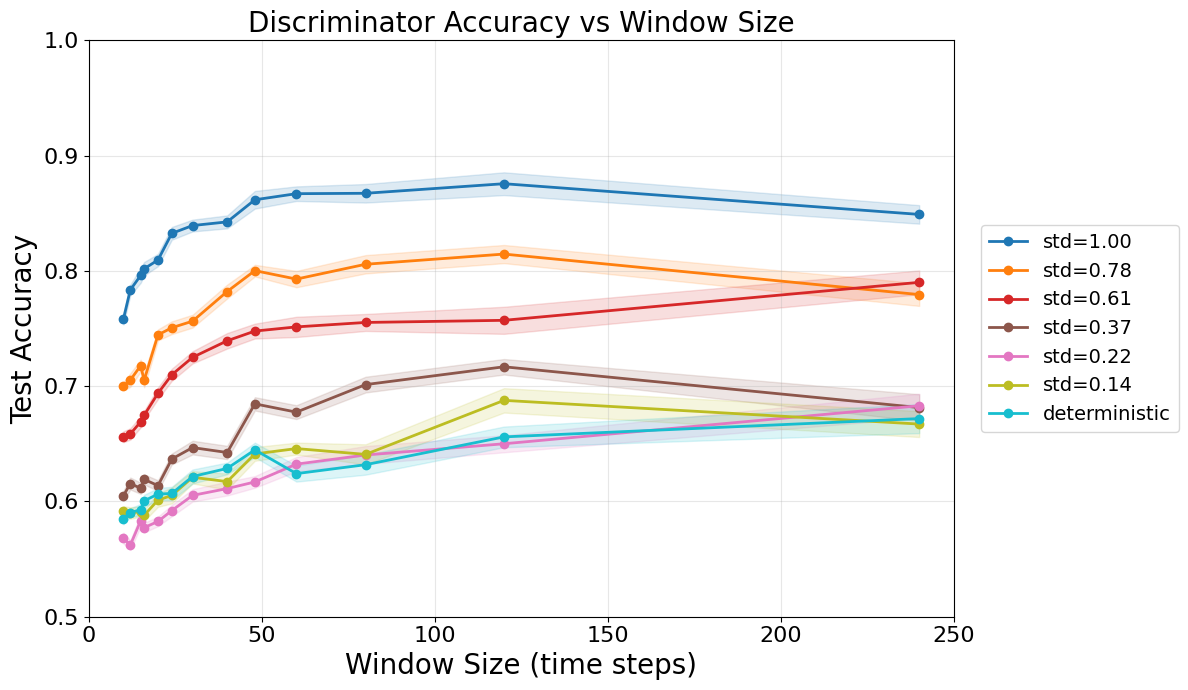

In [24]:
def get_std_from_name(ds_name):
    """Extract std value from dataset name (for sorting)."""
    if ds_name.startswith('logvar_'):
        logvar = float(ds_name.replace('logvar_', ''))
        return np.exp(logvar / 2)
    return None

def get_label(ds_name):
    """Convert dataset name to display label (logvar -> std)."""
    if ds_name == 'deterministic':
        return 'deterministic'
    if ds_name.startswith('logvar_'):
        std = get_std_from_name(ds_name)
        return f'std={std:.2f}'
    return ds_name

# Sort datasets: largest std first, deterministic last
logvar_datasets = [d for d in datasets if d.startswith('logvar_')]
logvar_datasets.sort(key=lambda d: get_std_from_name(d), reverse=True)
sorted_datasets = logvar_datasets + ['deterministic'] if 'deterministic' in datasets else logvar_datasets

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(sorted_datasets)))
window_sizes = df['window_size'].values

for idx, ds in enumerate(sorted_datasets):
    means = df[f'{ds}_mean'].values
    stds = df[f'{ds}_std'].values
    label = get_label(ds)
    
    ax.plot(window_sizes, means, color=colors[idx], linewidth=2,
            marker='o', markersize=6, label=label)
    ax.fill_between(window_sizes, means - stds, means + stds,
                    color=colors[idx], alpha=0.15)

ax.set_xlabel('Window Size (time steps)', fontsize=20)
ax.set_ylabel('Test Accuracy', fontsize=20)
ax.set_title('Discriminator Accuracy vs Window Size', fontsize=20)
ax.set_xlim(0, max(window_sizes) + 10)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=14, loc='center left', bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

## Compare Multiple Sweeps

Load and compare results from multiple sweep runs (e.g., MLP vs RNN)

In [ ]:
# Optional: compare multiple CSV files
CSV_PATHS = {
    # "MLP": "../results/discriminator_sweep_mlp/window_sweep_data.csv",
    # "RNN": "../results/discriminator_sweep_rnn/window_sweep_data.csv",
}

if CSV_PATHS:
    fig, ax = plt.subplots(figsize=(12, 7))
    linestyles = ['-', '--', ':', '-.']
    
    for run_idx, (run_name, csv_path) in enumerate(CSV_PATHS.items()):
        df_run = pd.read_csv(csv_path)
        mean_cols = [c for c in df_run.columns if c.endswith('_mean')]
        datasets = [c.replace('_mean', '') for c in mean_cols]
        window_sizes = df_run['window_size'].values
        colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))
        
        for idx, ds in enumerate(datasets):
            means = df_run[f'{ds}_mean'].values
            label = f"{ds} ({run_name})" if len(CSV_PATHS) > 1 else ds
            ax.plot(window_sizes, means, color=colors[idx],
                    linestyle=linestyles[run_idx % len(linestyles)],
                    linewidth=2, marker='o', markersize=5, label=label)
    
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random')
    ax.set_xlabel('Window Size', fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_title('Comparison of Discriminator Sweeps', fontsize=14)
    ax.legend(fontsize=9, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()